In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
data=pd.read_csv('ecommerce_customer_behavior_dataset.csv')
data.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [5]:
data.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


In [6]:
data.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [7]:
data.drop_duplicates(inplace=True)

In [3]:
data["Date"]=pd.to_datetime(data["Date"])

In [4]:
Total_Revenue = data["Total_Amount"].sum()
print(Total_Revenue)

4915544.57


In [5]:
Average_Revenue = data['Total_Amount'].mean()
print(Average_Revenue)

983.108914


In [6]:
Total_Order = data['Order_ID'].nunique()
print(Total_Order)

5000


In [7]:
Total_Customer= data['Customer_ID'].nunique()
print(Total_Customer)

5000


In [8]:
Average_Quantity= data['Quantity'].mean()
print(Average_Quantity)

2.22


In [9]:
Average_Customer= data['Customer_ID'].nunique()/data['Date'].nunique()
print(Average_Customer)

11.086474501108647


In [10]:
Average_Order= data['Order_ID'].nunique()/data['Date'].nunique()
print(Average_Order)

11.086474501108647


In [11]:
Average_pages_viewed= data['Pages_Viewed'].mean()
print(Average_pages_viewed)

8.9842


In [12]:
Top_product_Categories = data['Product_Category'].value_counts().head(5)
print(Top_product_Categories)

Product_Category
Sports           667
Electronics      624
Fashion          622
Beauty           621
Home & Garden    621
Name: count, dtype: int64


In [13]:
Mode_Age= data['Age'].mode()
print(Mode_Age)

0    18
Name: Age, dtype: int64


In [15]:
category_sales = data.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)
print(category_sales)

Product_Category
Electronics      2328806.81
Home & Garden     908348.86
Sports            754563.56
Fashion           375214.93
Toys              223142.48
Beauty            156584.74
Food               96138.67
Books              72744.52
Name: Total_Amount, dtype: float64


In [16]:
customer_df = data.groupby('Customer_ID').agg({
    
    'Total_Amount':'sum',
    'Order_ID':'count',
    'Quantity':'sum',
    'Session_Duration_Minutes':'mean',
    'Pages_Viewed':'mean',
    'Customer_Rating':'mean',
    'Is_Returning_Customer':'max'

}).reset_index()

In [17]:
customer_df.columns = [
    'Customer_ID',
    'Total_Spend',
    'Purchase_Frequency',
    'Total_Quantity',
    'Avg_Session',
    'Avg_Pages',
    'Avg_Rating',
    'Returning_Customer'
]

In [18]:
features = customer_df[[
    
    'Total_Spend',
    'Purchase_Frequency',
    'Total_Quantity',
    'Avg_Session',
    'Avg_Pages'

]]

In [19]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [20]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

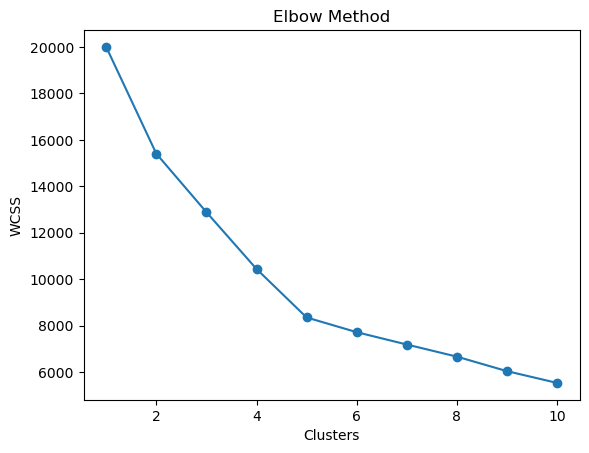

In [21]:
plt.plot(range(1,11),wcss,marker='o')

plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

customer_df['Cluster'] = kmeans.fit_predict(scaled_data)

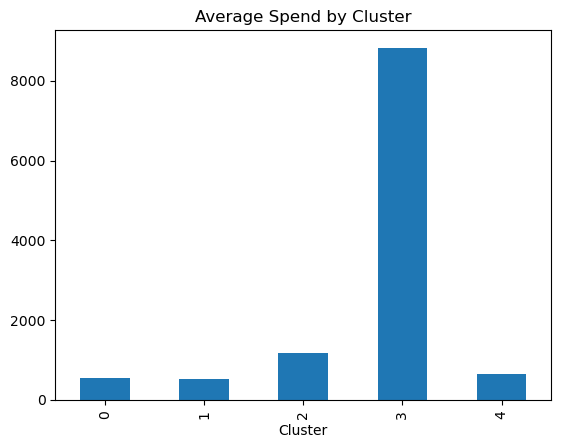

In [26]:
cluster_analysis = customer_df.groupby('Cluster').mean(numeric_only=True)

cluster_analysis['Total_Spend'].plot(
    kind='bar'
)

plt.title('Average Spend by Cluster')
plt.show()

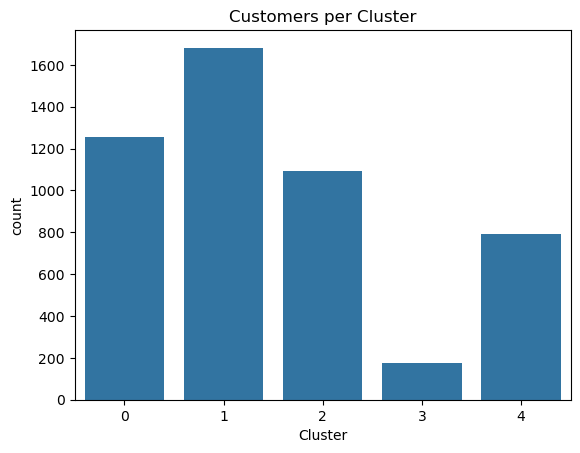

In [25]:
sns.countplot(
    x='Cluster',
    data=customer_df
)

plt.title('Customers per Cluster')

plt.show()

In [27]:
customer_df.groupby('Cluster').agg({
    
    'Total_Spend':'mean',
    'Purchase_Frequency':'mean',
    'Total_Quantity':'mean',
    'Avg_Session':'mean',
    'Avg_Pages':'mean'

}).round(2)

,Total_Spend,Purchase_Frequency,Total_Quantity,Avg_Session,Avg_Pages
Cluster,,,,,
0,546.62,1.0,1.51,11.89,12.00
1,526.50,1.0,1.43,11.05,6.92
2,1168.63,1.0,4.26,12.85,8.86
3,8824.56,1.0,3.82,13.45,8.88
4,657.33,1.0,1.85,28.94,8.78


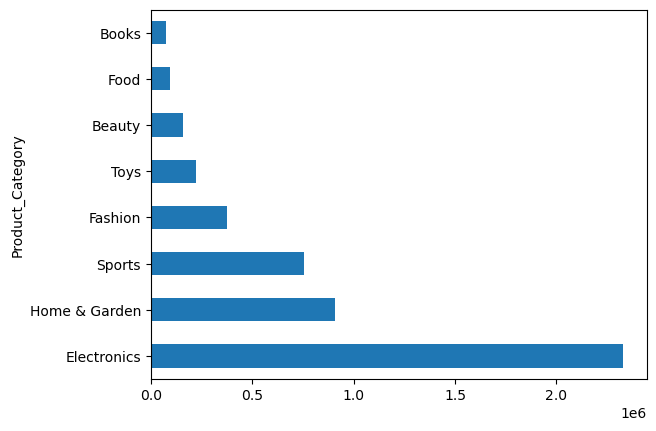

In [34]:
category_sales.plot(kind='barh')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_24076\1461703059.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_spend = data.groupby('Age_Group')['Total_Amount'].mean().reset_index()


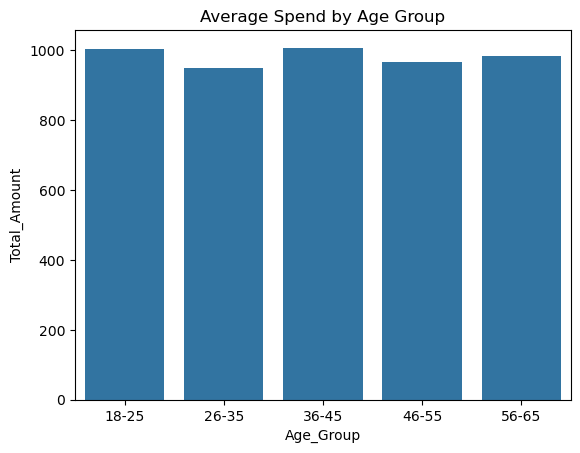

In [37]:
data['Age_Group'] = pd.cut(
    data['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

age_group_spend = data.groupby('Age_Group')['Total_Amount'].mean().reset_index()

sns.barplot(
    data=age_group_spend,
    x='Age_Group',
    y='Total_Amount'
)

plt.title('Average Spend by Age Group')
plt.show()

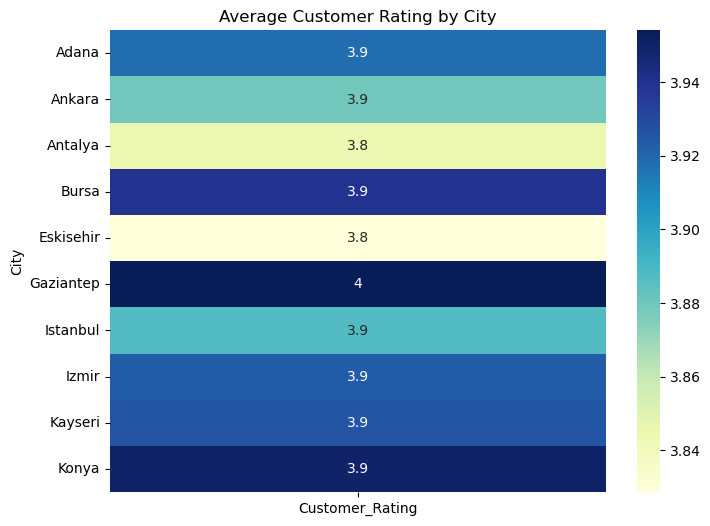

In [38]:
city_rating = data.groupby('City')['Customer_Rating'].mean().reset_index()

pivot = city_rating.set_index('City')

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title('Average Customer Rating by City')
plt.show()

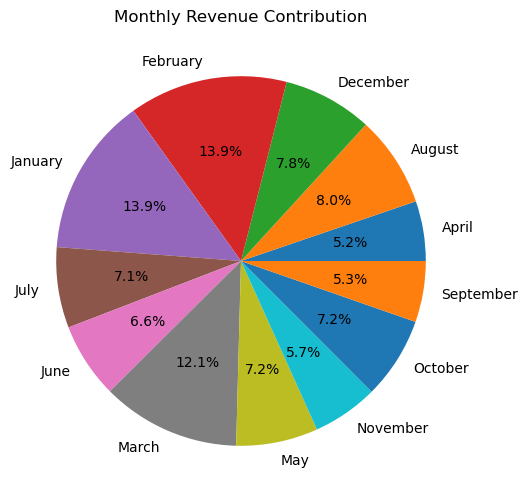

In [45]:
monthly_sales = data.groupby(data['Date'].dt.month_name())['Total_Amount'].sum()

plt.figure(figsize=(8,6))

plt.pie(
    monthly_sales,
    labels=monthly_sales.index,
    autopct='%1.1f%%'
)

plt.title('Monthly Revenue Contribution')
plt.show()

In [ ]:
print("Business Recommendations:")
print("1.Run promotional offers and marketing campaigns between September and November to increase sales. ")
print("2.Introduce loyalty programs and rewards to encourage repeat purchases and customer retention.")
print("3.Optimize the online shopping experience to improve customer satisfaction.")
print("4.Improve product variety and marketing for Books, Food, Beauty, and Toys categories to boost sales.")
print("5.Enhance customer service and delivery quality in areas with lower customer ratings to improve satisfaction.")

Business Recommendations:
1.Run promotional offers and marketing campaigns between September and November to increase sales. 
2.Introduce loyalty programs and rewards to encourage repeat purchases and customer retention.
3.Optimize the online shopping experience to improve customer satisfaction.
4.Improve product variety and marketing for Books, Food, Beauty, and Toys categories to boost sales.
5.Enhance supply chain efficiency to reduce delivery times and costs.
